In [1]:
import pandas as pd
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error, r2_score


import os
from multiprocessing import Process


os.makedirs("../results/experiment_15_v3", exist_ok=True)

In [2]:
dataset = pd.read_csv("../dataset/riemann_features.csv")

features = pd.read_csv("../results/data_analysis/selected_features.csv")["feature"].tolist()

X = dataset.drop(columns=["distance"])
y = dataset["distance"]

X = X[:2000]
y = y[:2000]

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1600, 94) (1600,)
(400, 94) (400,)


# Classical SVR

In [3]:
def run_classical_experiment():
    results = []

    param_grid = {
        "svr__C": [0.1, 1, 5, 10],
        "svr__epsilon": [0.001, 0.01, 0.1, 0.5],
        "svr__gamma": ["scale", 0.01, 0.1, 1.0]
    }

    n_features = [i for i in range(1, 11)]

    for n in n_features:
        print(f"Running experiment for group: Rank Aggregation with {n} features")

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        pipeline = Pipeline([
            ("scaler", MinMaxScaler()),
            ("svr", SVR(kernel="rbf"))
        ])

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_root_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=3),
            n_jobs=-1
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test_subset)

        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "RMSE": rmse,
            "R2": r2,
            "Best C": grid.best_params_["svr__C"],
            "Best epsilon": grid.best_params_["svr__epsilon"],
            "Best gamma": grid.best_params_["svr__gamma"],
            "Features": n
        })

    results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
    print(results_df)
    results_df.to_csv("../results/experiment_15_v3/classical_experiment_results.csv", index=False)


In [4]:
run_classical_experiment()

Running experiment for group: Rank Aggregation with 1 features
Running experiment for group: Rank Aggregation with 2 features
Running experiment for group: Rank Aggregation with 3 features
Running experiment for group: Rank Aggregation with 4 features
Running experiment for group: Rank Aggregation with 5 features
Running experiment for group: Rank Aggregation with 6 features
Running experiment for group: Rank Aggregation with 7 features
Running experiment for group: Rank Aggregation with 8 features
Running experiment for group: Rank Aggregation with 9 features
Running experiment for group: Rank Aggregation with 10 features
       RMSE        R2  Best C  Best epsilon Best gamma  Features
0  0.057858  0.958818      10         0.001      scale         9
1  0.064620  0.948630      10         0.010      scale         6
2  0.070752  0.938417       5         0.010      scale        10
3  0.070840  0.938264      10         0.001      scale         8
4  0.075013  0.930776      10         0.010 

# Quantum SVR - DoubleAngleEntangledFeatureMap

In [5]:
def feature_map(x, wires):
    qml.AngleEmbedding(x, wires=wires, rotation="X")

    qml.BasicEntanglerLayers(
        weights=0.1*np.ones((1, len(wires))),
        wires=wires,
        rotation=qml.RZ
    )

    for i in range(len(wires)):
        qml.RZ(
            0.2*np.sin(x[i]) + 0.1*np.cos(2*x[i]),
            wires=wires[i]
        )

    qml.AngleEmbedding(x, wires=wires, rotation="Y")


def make_simple_kernel(n_qubits):
    dev = qml.device("lightning.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def kernel_fn(x1, x2):
        wires = range(n_qubits)
        feature_map(x1, wires=wires)
        qml.adjoint(feature_map)(x2, wires=wires)
        return qml.expval(qml.Projector([0] * n_qubits, wires=wires))

    return kernel_fn

## DoubleAngleEntangledFeatureMap Circuit

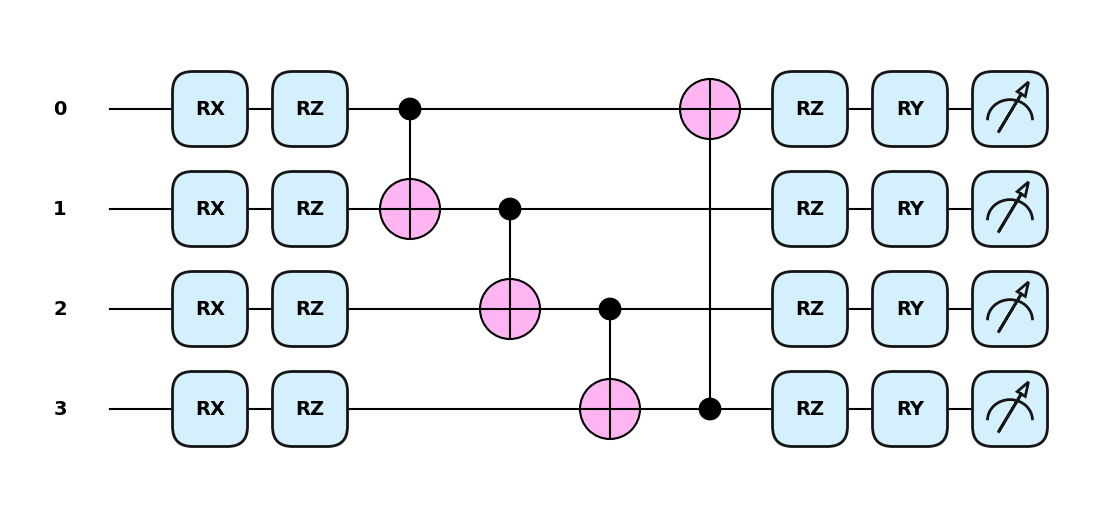

In [6]:
n_qubits = 4
x_example = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev)
def encoding_circuit(x):
    feature_map(x, wires=range(n_qubits))
    return qml.state()


fig, ax = qml.draw_mpl(
    encoding_circuit,
    style="pennylane",
    level="device"
)(x_example)

plt.savefig("../results/experiment_15_v3/double_angle_entangled_feature_map.png", dpi=160, bbox_inches='tight')
plt.show()

# Quantum SVR - EntangledPolynomialFeatureMap

In [7]:
def enhanced_feature_map(x, wires, reps=1):
    for _ in range(reps):
        qml.AngleEmbedding(x, wires=wires, rotation="X")
        qml.AngleEmbedding(x, wires=wires, rotation="Z")

        for i in range(len(wires)):
            for j in range(i + 1, len(wires)):
                qml.IsingZZ(x[i] * x[j], wires=[wires[i], wires[j]])

        qml.AngleEmbedding(x, wires=wires, rotation="Y")


def make_enhanced_kernel(n_qubits, reps=1):
    dev = qml.device("lightning.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def kernel_fn(x1, x2):
        wires = range(n_qubits)

        enhanced_feature_map(x1, wires=wires, reps=reps)
        qml.adjoint(enhanced_feature_map)(x2, wires=wires, reps=reps)

        return qml.expval(qml.Projector([0] * n_qubits, wires=wires))

    return kernel_fn

## EntangledPolynomialFeatureMap - Circuit

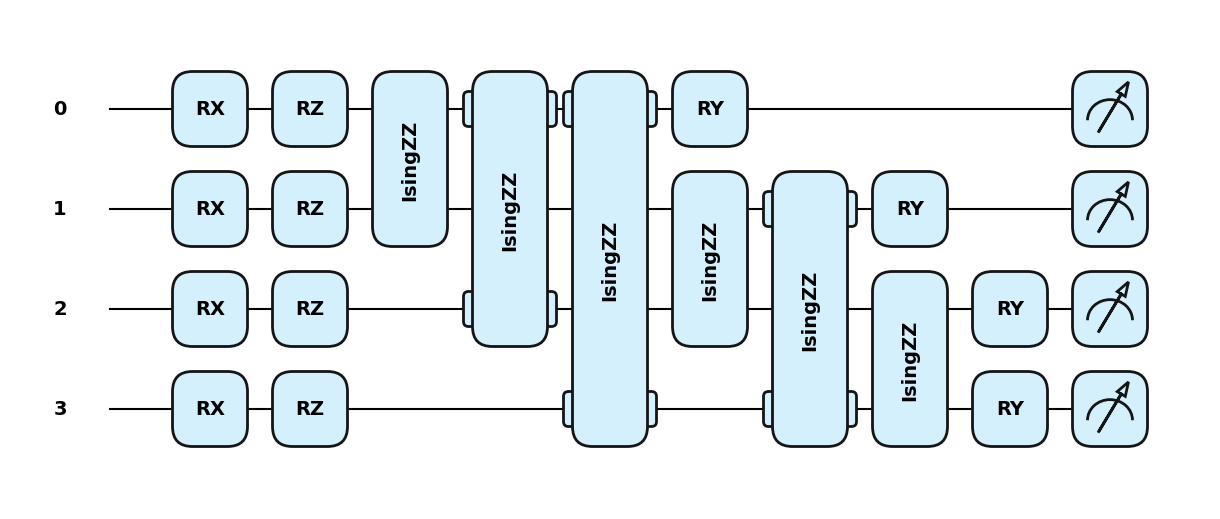

In [8]:
n_qubits = 4
x_example = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev)
def encoding_circuit(x):
    enhanced_feature_map(x, wires=range(n_qubits))
    return qml.state()


fig, ax = qml.draw_mpl(
    encoding_circuit,
    style="pennylane",
    level="device"
)(x_example)

plt.savefig("../results/experiment_15_v3/enhanced_feature_map.png", dpi=160, bbox_inches='tight')
plt.show()

In [9]:
def fourier_feature_map(x, wires):
    for i in range(len(wires)):
        qml.RX(x[i], wires=wires[i])
        qml.RZ(x[i], wires=wires[i])

    for i in range(len(wires)-1):
        qml.CNOT(wires=[wires[i], wires[i+1]])

    for i in range(len(wires)):
        qml.RZ(np.sin(x[i]) + np.cos(2*x[i]), wires=wires[i])


def make_fourier_kernel(n_qubits):
    dev = qml.device("lightning.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def kernel_fn(x1, x2):
        wires = range(n_qubits)

        fourier_feature_map(x1, wires=wires)
        qml.adjoint(fourier_feature_map)(x2, wires=wires)

        return qml.expval(qml.Projector([0] * n_qubits, wires=wires))

    return kernel_fn

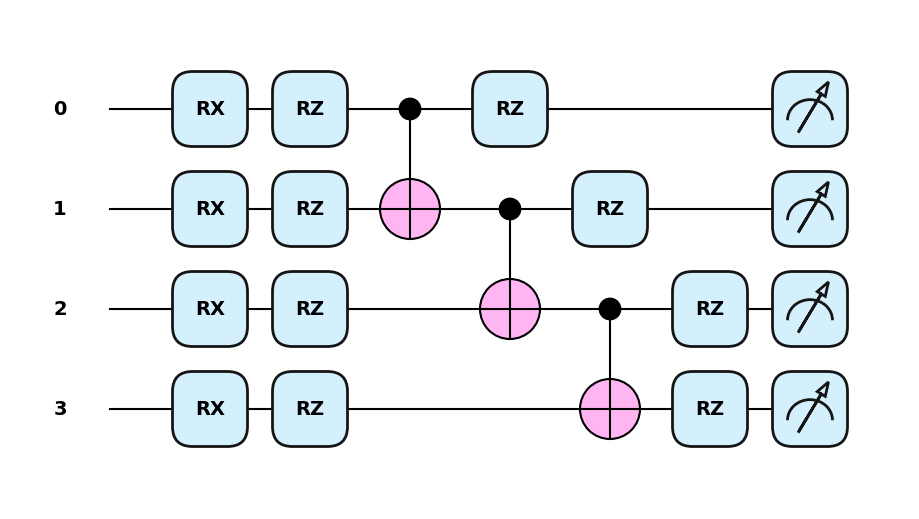

In [10]:
n_qubits = 4
x_example = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev)
def encoding_circuit(x):
    fourier_feature_map(x, wires=range(n_qubits))
    return qml.state()


fig, ax = qml.draw_mpl(
    encoding_circuit,
    style="pennylane",
    level="device"
)(x_example)

plt.savefig("../results/experiment_15_v3/fourier_feature_map.png", dpi=160, bbox_inches='tight')
plt.show()

In [11]:
def run_simple_experiment():
    results = []
    kernels = {
        "6_simple": (make_simple_kernel(6), 6),
        "8_simple":  (make_simple_kernel(8), 8),
        "9_simple":  (make_simple_kernel(9), 9),
        "10_simple": (make_simple_kernel(10), 10),
    }

    param_grid = {
        "svr__C": [1, 5],
        "svr__epsilon": [0.01, 0.1]
    }

    for name, (kernel, n) in kernels.items():
        print(f"Running kernel {name}")

        kernel_mat = lambda A, B, kf=kernel: qml.kernels.kernel_matrix(A, B, kf)

        pipeline = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
            ("svr", SVR(kernel=kernel_mat))
        ])

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_root_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)
        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Kernel: {name}, RMSE: {rmse:.4f}, R^2: {r2:.4f}")
        results.append({
            "kernel": name,
            "rmse": rmse,
            "r2": r2,
            "best_c": grid.best_params_["svr__C"],
            "best_epsilon": grid.best_params_["svr__epsilon"]
        })

    results_df = pd.DataFrame(results)
    print(results_df)
    results_df\
        .sort_values("rmse")\
        .to_csv("../results/experiment_15_v3/simple_experiment_results.csv", index=False)


In [12]:
def run_enhanced_experiment():
    reps = 1
    results = []
    kernels = {
        "1_enhanced":  (make_enhanced_kernel(1, reps), 1),
        "2_enhanced":  (make_enhanced_kernel(2, reps), 2),
        "3_enhanced":  (make_enhanced_kernel(3, reps), 3),
        "4_enhanced":  (make_enhanced_kernel(4, reps), 4),
        "5_enhanced":  (make_enhanced_kernel(5, reps), 5),
        "6_enhanced":  (make_enhanced_kernel(6, reps), 6),
        "8_enhanced":  (make_enhanced_kernel(8, reps), 8),
        "9_enhanced":  (make_enhanced_kernel(9, reps), 9),
        "10_enhanced": (make_enhanced_kernel(10, reps), 10),
    }

    param_grid = {
        "svr__C": [1, 5],
        "svr__epsilon": [0.01, 0.1]
    }

    for name, (kernel, n) in kernels.items():
        print(f"Running kernel {name}")

        kernel_mat = lambda A, B, kf=kernel: qml.kernels.kernel_matrix(A, B, kf)

        pipeline = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
            ("svr", SVR(kernel=kernel_mat))
        ])

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_root_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)
        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Kernel: {name}, RMSE: {rmse:.4f}, R^2: {r2:.4f}")
        results.append({
            "kernel": name,
            "rmse": rmse,
            "r2": r2,
            "best_c": grid.best_params_["svr__C"],
            "best_epsilon": grid.best_params_["svr__epsilon"]
        })


    results_df = pd.DataFrame(results)
    print(results_df)
    results_df\
        .sort_values("rmse")\
        .to_csv("../results/experiment_15_v3/enhanced_experiment_results.csv", index=False)


In [13]:
def run_fourier_experiment():
    results = []
    kernels = {
        "4_fourier": (make_fourier_kernel(4), 4),
        "6_fourier": (make_fourier_kernel(6), 6),
        "8_fourier": (make_fourier_kernel(8), 8),
        "9_fourier": (make_fourier_kernel(9), 9),
        "10_fourier": (make_fourier_kernel(10), 10),
    }

    param_grid = {
        "svr__C": [1, 5],
        "svr__epsilon": [0.01, 0.1]
    }

    for name, (kernel, n) in kernels.items():
        print(f"Running kernel {name}")

        kernel_mat = lambda A, B, kf=kernel: qml.kernels.kernel_matrix(A, B, kf)

        pipeline = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
            ("svr", SVR(kernel=kernel_mat))
        ])

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_root_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)
        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Kernel: {name}, RMSE: {rmse:.4f}, R^2: {r2:.4f}")
        results.append({
            "kernel": name,
            "rmse": rmse,
            "r2": r2,
            "best_c": grid.best_params_["svr__C"],
            "best_epsilon": grid.best_params_["svr__epsilon"]
        })


    results_df = pd.DataFrame(results)
    print(results_df)
    results_df\
        .sort_values("rmse")\
        .to_csv("../results/experiment_15_v3/fourier_experiment_results.csv", index=False)


In [14]:
p_simple_process = Process(target=run_simple_experiment)
p_enhanced_process = Process(target=run_enhanced_experiment)
p_fourier_process = Process(target=run_fourier_experiment)

p_simple_process.start()
p_enhanced_process.start()
p_fourier_process.start()
p_simple_process.join()
p_enhanced_process.join()
p_fourier_process.join()

Running kernel 6_simple
Running kernel 1_enhanced
Running kernel 4_fourier


Process Process-9:
Process Process-11:
Process Process-10:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/gabriel/Documents/ic_qc/rgpe/venv/lib64/python3.13/site-packages/sklearn/model_selection/_search.py", line 999, in evaluate_candidates
    out = parallel(
        delayed(_fit_and_score)(
    ...<13 lines>...
        )
    )
  File "/usr/lib64/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/usr/lib64/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/usr/lib64/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib64/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/tmp/ipykernel_321844/2541368088.py", line 35, in run_simple_experiment
    grid.f

KeyboardInterrupt: 